# The Fourier Transform of the Dirac Comb

This notebook builds intuition for why the Fourier transform of a Dirac comb is itself a Dirac comb.
We start with a single impulse at the origin and progressively add impulses symmetrically, watching
the frequency-domain representation evolve.

For each configuration we show three panels:
- **Real part** of the normalised Fourier transform
- **Imaginary part** of the normalised Fourier transform
- **Power Spectral Density (PSD)** = |F(f)/N|²

All transforms are **normalised by the number of impulses N** so that the peak amplitude
is always 1. This keeps the y-axis fixed across all sections, making the progressive
sharpening of the comb directly visible.

**Reference:** VanderPlas (2018), ApJS 236, 16 — *Understanding the Lomb-Scargle Periodogram*

## Background

The Fourier transform of a time-domain signal $g(t)$ is defined as:

$$\hat{g}(f) = \int_{-\infty}^{\infty} g(t)\, e^{-2\pi i f t}\, dt$$

For a Dirac delta function at position $t_0$, the sifting property gives:

$$\mathcal{F}\{\delta(t - t_0)\} = e^{-2\pi i f t_0} = \cos(2\pi f t_0) - i\sin(2\pi f t_0)$$

Key observations:
- At $t_0 = 0$: transform $= 1$ (purely real, flat spectrum)
- At $t_0 \neq 0$: both real and imaginary parts are non-zero
- The PSD $= |e^{-2\pi i f t_0}|^2 = \cos^2 + \sin^2 = 1$ always — flat regardless of impulse location

By linearity, for a symmetric arrangement of $N$ impulses at $t = 0, \pm T, \pm 2T, \ldots$:

$$\hat{g}(f) = 1 + 2\sum_{n=1}^{M} \cos(2\pi f n T) \quad \text{(purely real, } N = 2M+1 \text{ impulses)}$$

Normalised by $N$, the peak value at $f = k/T$ is always 1, while the between-peak
regions shrink toward zero as more pairs are added.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ────────────────────────────────────────────────────────────────
T   = 1.0                          # impulse spacing (normalised)
N_f = 5000                         # number of frequency points
f   = np.linspace(-4/T, 4/T, N_f)  # frequency axis (show ±4 comb teeth)

# Colour scheme
C_REAL = '#2166ac'   # blue  — real part
C_IMAG = '#d6604d'   # red   — imaginary part
C_PSD  = '#1a9850'   # green — PSD

def plot_transform(f, F, title, n_impulses=1):
    """Plot real, imaginary, and PSD panels for a Fourier transform F(f).

    Normalises by n_impulses so all sections share the same y-scale.
    Peak amplitude = 1 throughout, making progressive sharpening visible.
    """
    F_norm = F / n_impulses
    PSD    = np.abs(F_norm)**2
    s      = 's' if n_impulses > 1 else ''

    fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
    fig.suptitle(f'{title}\n(normalised by {n_impulses} impulse{s})',
                 fontsize=12, fontweight='bold')

    axes[0].plot(f, F_norm.real, color=C_REAL, lw=1.5)
    axes[0].axhline(0, color='k', lw=0.5, ls='--')
    axes[0].set_ylabel('Real part', fontsize=10)
    axes[0].set_ylim(-1.5, 1.5)
    axes[0].grid(ls=':', lw=0.5, alpha=0.5)

    axes[1].plot(f, F_norm.imag, color=C_IMAG, lw=1.5)
    axes[1].axhline(0, color='k', lw=0.5, ls='--')
    axes[1].set_ylabel('Imaginary part', fontsize=10)
    axes[1].set_ylim(-1.5, 1.5)
    axes[1].grid(ls=':', lw=0.5, alpha=0.5)

    axes[2].plot(f, PSD, color=C_PSD, lw=1.5)
    axes[2].axhline(0, color='k', lw=0.5, ls='--')
    axes[2].set_ylabel('PSD  |F(f)/N|²', fontsize=10)
    axes[2].set_xlabel('Frequency  f  (units of 1/T)', fontsize=10)
    axes[2].set_ylim(-0.1, 1.5)
    axes[2].grid(ls=':', lw=0.5, alpha=0.5)

    # Mark comb tooth positions
    for ax in axes:
        for k in range(-4, 5):
            ax.axvline(k/T, color='grey', lw=0.5, ls=':', alpha=0.4)

    axes[2].set_xlim(f[0], f[-1])
    fig.tight_layout()
    plt.show()

print(f'Setup complete.  T = {T},  frequency axis: {f[0]:.1f} to {f[-1]:.1f}')

Setup complete.  T = 1.0,  frequency axis: -4.0 to 4.0


---
## Section 1: Single impulse at the origin  $\delta(t=0)$

$$\mathcal{F}\{\delta(t)\} = e^{-2\pi i f \cdot 0} = 1$$

The transform is **1** at every frequency — flat real part, zero imaginary part, PSD flat at 1.

An impulse at the origin has a perfectly symmetric relationship with the frequency axis:
there is no preferred direction in time, so there is no phase — the imaginary part is identically zero.

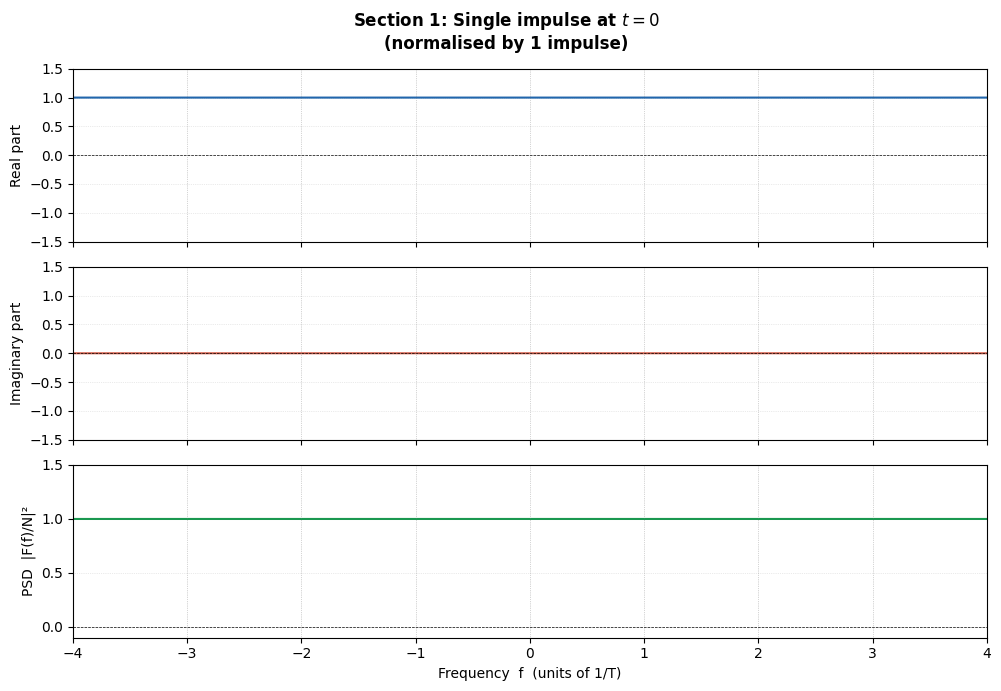

In [2]:
F1 = np.ones_like(f, dtype=complex)   # e^{-2pi i f * 0} = 1
plot_transform(f, F1,
    title=r'Section 1: Single impulse at $t = 0$',
    n_impulses=1)

---
## Section 2: Single impulse at $t = +T$

$$\mathcal{F}\{\delta(t - T)\} = e^{-2\pi i f T} = \cos(2\pi f T) - i\sin(2\pi f T)$$

Moving the impulse off the origin **activates the imaginary part**.
The phase winds linearly with frequency at a rate proportional to $T$.

Note that the **PSD is still flat at 1** — the timing information is carried entirely
in the phase (imaginary part), which the PSD discards.
A spectrum analyser cannot tell you where in time this impulse occurred.

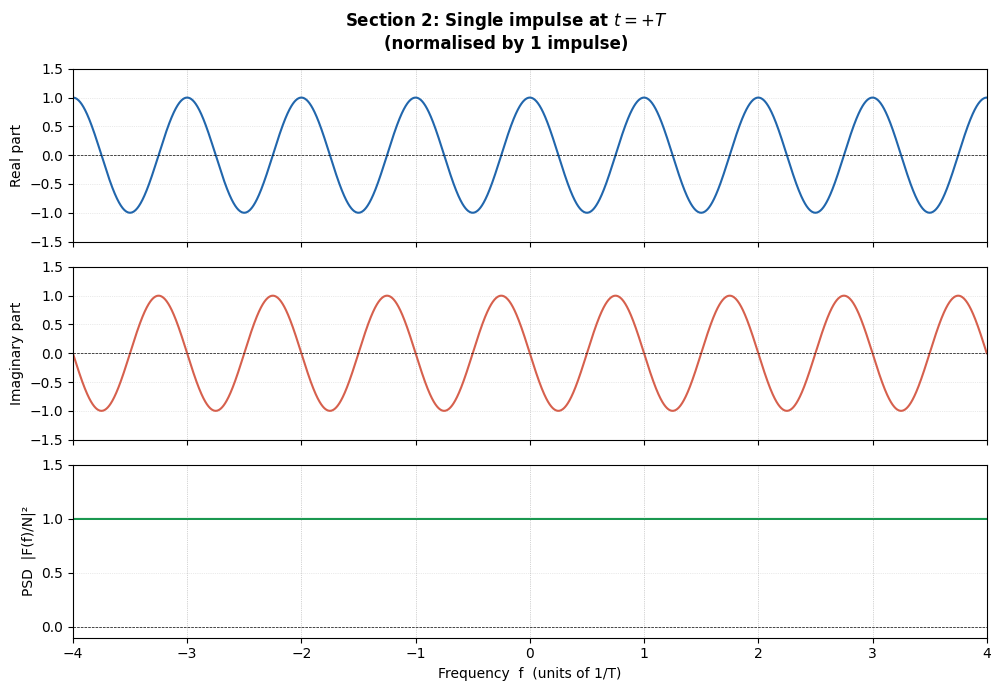

In [3]:
F2 = np.exp(-2j * np.pi * f * T)   # delta at +T
plot_transform(f, F2,
    title=r'Section 2: Single impulse at $t = +T$',
    n_impulses=1)

---
## Section 3: Single impulse at $t = -T$

$$\mathcal{F}\{\delta(t + T)\} = e^{+2\pi i f T} = \cos(2\pi f T) + i\sin(2\pi f T)$$

The real part is **identical** to Section 2 — cosine is an even function so $\cos(2\pi f T) = \cos(-2\pi f T)$.

But the imaginary part has **flipped sign** — the sine term changes sign with the shift direction.

The PSD is still flat at 1 — you cannot distinguish $\delta(t-T)$ from $\delta(t+T)$ from the PSD alone.
This is a direct demonstration that PSD discards timing information.

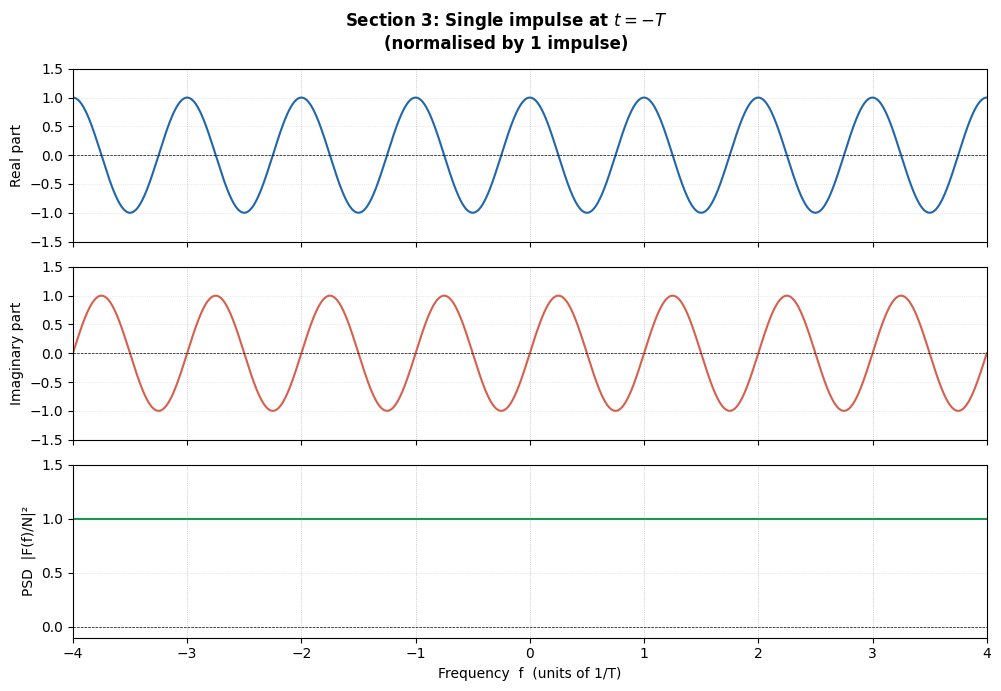

In [4]:
F3 = np.exp(+2j * np.pi * f * T)   # delta at -T
plot_transform(f, F3,
    title=r'Section 3: Single impulse at $t = -T$',
    n_impulses=1)

---
## Section 4: Three impulses — $\delta(-T) + \delta(0) + \delta(+T)$

By linearity:

$$\mathcal{F}\{\delta(t+T) + \delta(t) + \delta(t-T)\} = e^{+2\pi ifT} + 1 + e^{-2\pi ifT} = 1 + 2\cos(2\pi fT)$$

The sine terms from $\pm T$ are **equal and opposite and cancel exactly**.
The imaginary part is identically zero.

This is not a coincidence — it is a theorem:
> **An even function (symmetric about $t=0$) always has a purely real Fourier transform.**

The real part now shows oscillation — the first hint of comb structure.
After normalisation by $N=3$ the peak is 1 and the troughs dip below zero.

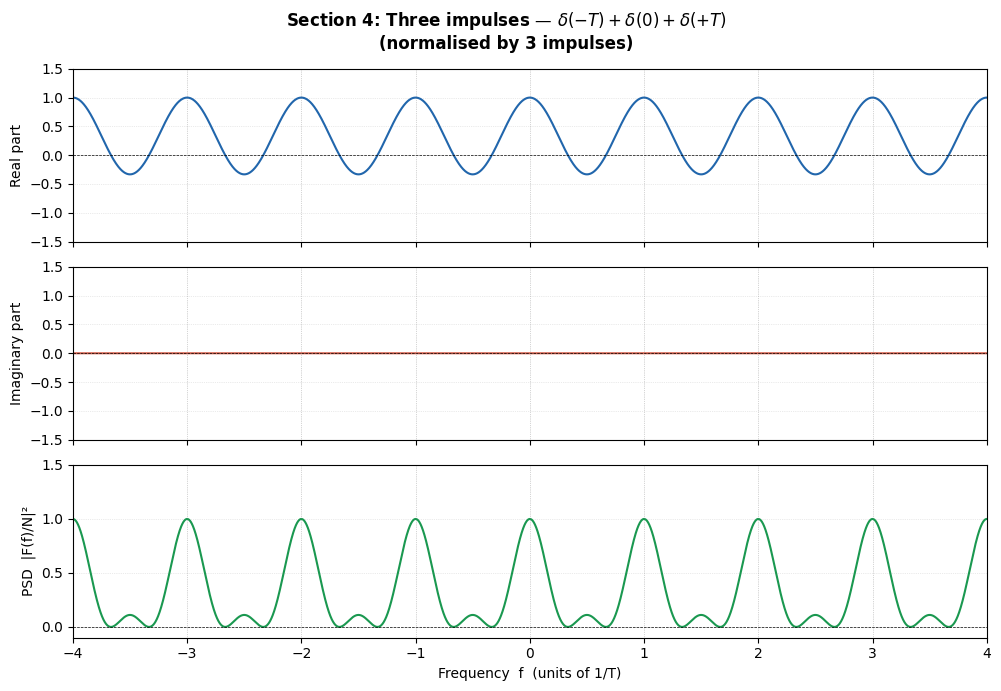

In [5]:
F4 = np.ones_like(f, dtype=complex)   # delta at 0
F4 += np.exp(-2j * np.pi * f * T)     # delta at +T
F4 += np.exp(+2j * np.pi * f * T)     # delta at -T
# Equivalently: 1 + 2*cos(2*pi*f*T)
plot_transform(f, F4,
    title=r'Section 4: Three impulses — $\delta(-T) + \delta(0) + \delta(+T)$',
    n_impulses=3)

---
## Section 5: Add pair at $\pm 2T$ — five impulses total

$$\hat{g}(f) = 1 + 2\cos(2\pi fT) + 2\cos(4\pi fT)$$

Each symmetric pair contributes another cosine harmonic.
At $f = k/T$ all cosines equal 1 — constructive interference.
Between those frequencies the cosines increasingly cancel.

After normalisation by $N=5$ the peak remains at 1. The troughs are suppressing further.

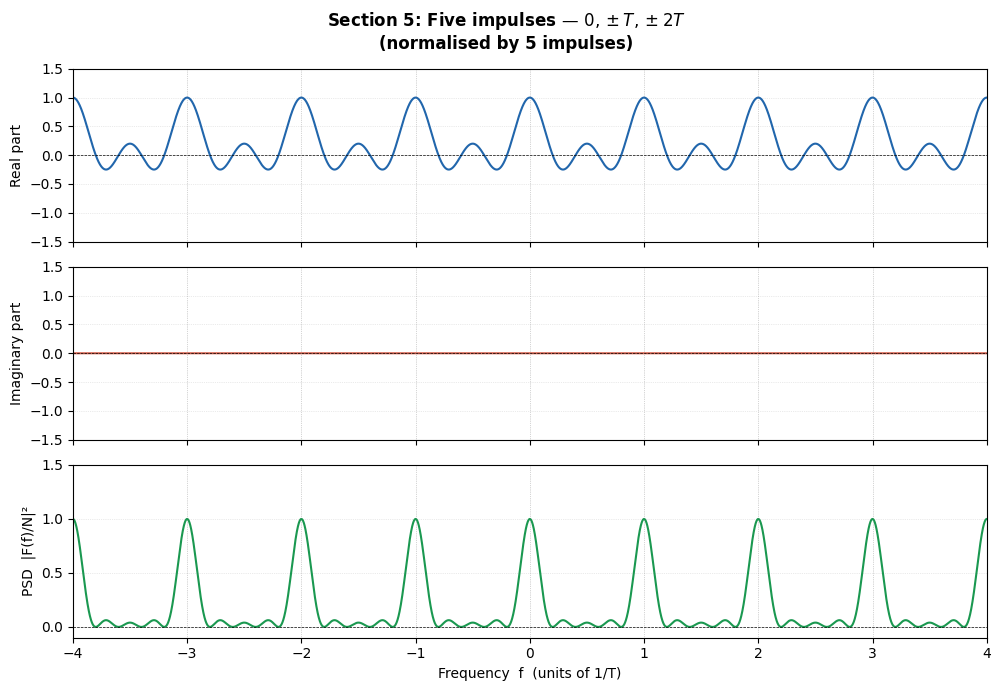

In [6]:
F5 = F4.copy()
F5 += np.exp(-2j * np.pi * f * 2*T)   # delta at +2T
F5 += np.exp(+2j * np.pi * f * 2*T)   # delta at -2T
plot_transform(f, F5,
    title=r'Section 5: Five impulses — $0, \pm T, \pm 2T$',
    n_impulses=5)

---
## Section 6: Add pair at $\pm 3T$ — seven impulses total

$$\hat{g}(f) = 1 + 2\cos(2\pi fT) + 2\cos(4\pi fT) + 2\cos(6\pi fT)$$

The peaks at $f = k/T$ are sharpening.
The between-peak regions are increasingly suppressed by destructive interference.
Imaginary part remains exactly zero throughout — the even-function theorem holds at every step.

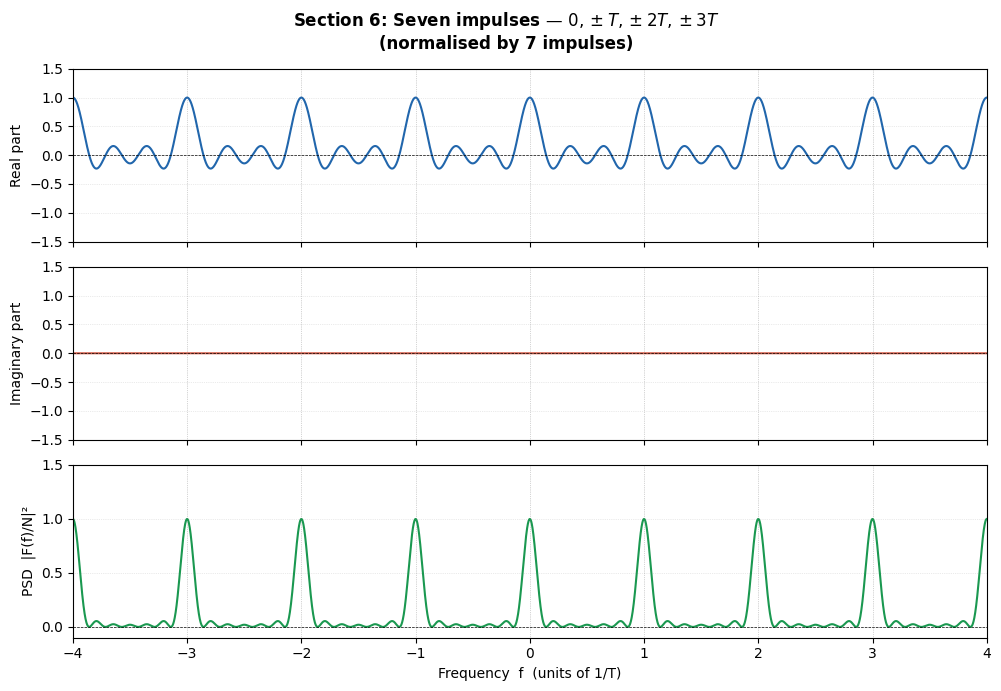

In [7]:
F6 = F5.copy()
F6 += np.exp(-2j * np.pi * f * 3*T)
F6 += np.exp(+2j * np.pi * f * 3*T)
plot_transform(f, F6,
    title=r'Section 6: Seven impulses — $0, \pm T, \pm 2T, \pm 3T$',
    n_impulses=7)

---
## Section 7: Add pair at $\pm 4T$ — nine impulses total

$$\hat{g}(f) = 1 + 2\sum_{n=1}^{4}\cos(2\pi f n T)$$

The comb structure is now clearly visible.
Peaks are narrow and well-separated; sidelobes between them are small.

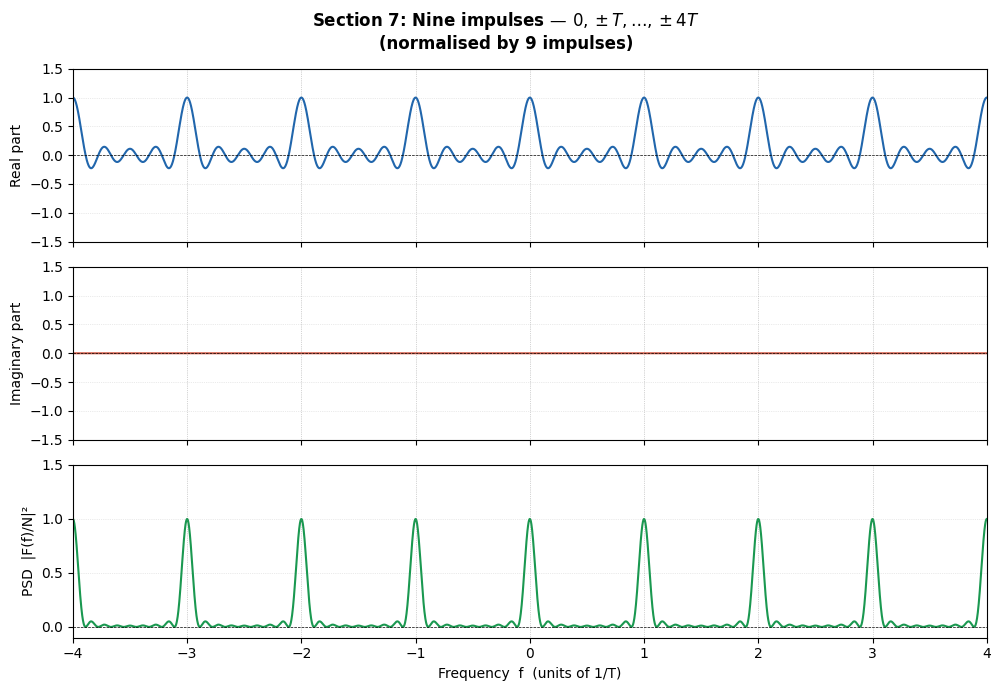

In [8]:
F7 = F6.copy()
F7 += np.exp(-2j * np.pi * f * 4*T)
F7 += np.exp(+2j * np.pi * f * 4*T)
plot_transform(f, F7,
    title=r'Section 7: Nine impulses — $0, \pm T, \ldots, \pm 4T$',
    n_impulses=9)

---
## Section 8: Add pair at $\pm 5T$ — eleven impulses total

$$\hat{g}(f) = 1 + 2\sum_{n=1}^{5}\cos(2\pi f n T)$$

The Dirac comb in frequency is clearly emerging.
Sharp peaks at $f = k/T$, near-zero between them.
In the limit $N \to \infty$ the peaks become true Dirac delta functions
and the between-peak values go to exactly zero.

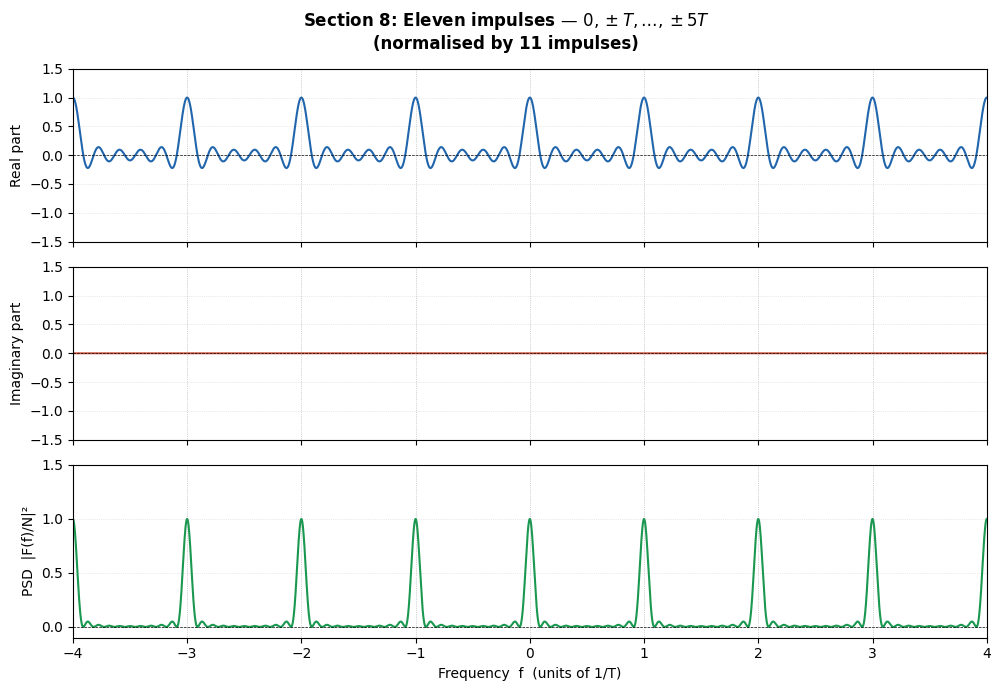

In [9]:
F8 = F7.copy()
F8 += np.exp(-2j * np.pi * f * 5*T)
F8 += np.exp(+2j * np.pi * f * 5*T)
plot_transform(f, F8,
    title=r'Section 8: Eleven impulses — $0, \pm T, \ldots, \pm 5T$',
    n_impulses=11)

---
## Section 10: Summary — Evolution of the real part and PSD

All configurations overlaid. Each curve is normalised by its own $N$ so the
peak amplitude is 1 throughout — only the **shape** changes.

Key takeaways:
1. **The imaginary part is identically zero** for all symmetric configurations — verified numerically below.
2. **The real part sharpens progressively** into peaks at $f = k/T$.
3. **The PSD sharpens** correspondingly — power concentrates at the harmonic frequencies.
4. **In the limit** of an infinite symmetric train, both converge to a Dirac comb with spacing $1/T$.
5. **PSD of a single impulse is always flat** regardless of its time location — timing lives in the phase only.

In [ ]:
# Recompute F9 on the original coarse f array for the overlay.
# At N=201 the peaks are underresolved on this grid (~3 pts/peak) but
# they appear as sharp spikes — which is exactly the right visual impression.
F9_summary = np.ones_like(f, dtype=complex)
for n in range(1, 101):
    F9_summary += np.exp(-2j * np.pi * f * n * T)
    F9_summary += np.exp(+2j * np.pi * f * n * T)

configs = [
    (F1,          1,   r'$\delta(0)$ only',            '#aaaaaa'),
    (F4,          3,   r'$\pm T$ added  (N=3)',         '#abd9e9'),
    (F5,          5,   r'$\pm 2T$ added (N=5)',         '#74add1'),
    (F6,          7,   r'$\pm 3T$ added (N=7)',         '#4575b4'),
    (F7,          9,   r'$\pm 4T$ added (N=9)',         '#313695'),
    (F8,         11,   r'$\pm 5T$ added (N=11)',        '#08003f'),
    (F9_summary, 201,  r'$\pm 100T$ added (N=201)',     '#8b0000'),
]

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
fig.suptitle('Section 10: Convergence to the Dirac Comb in Frequency\n'
             '(each curve normalised by its own N)',
             fontsize=13, fontweight='bold')

for F, N, label, color in configs:
    lw   = 2.0 if N == 201 else 1.4
    F_norm = F / N
    axes[0].plot(f, F_norm.real,       color=color, lw=lw, label=label)
    axes[1].plot(f, np.abs(F_norm)**2, color=color, lw=lw, label=label)

for ax in axes:
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.grid(ls=':', lw=0.5, alpha=0.5)
    for k in range(-4, 5):
        ax.axvline(k/T, color='grey', lw=0.5, ls=':', alpha=0.4)
    ax.legend(fontsize=8, loc='upper right', ncol=2)

axes[0].set_ylabel('Real part (normalised)', fontsize=10)
axes[0].set_ylim(-1.5, 1.5)
axes[1].set_ylabel('PSD  |F(f)/N|²', fontsize=10)
axes[1].set_ylim(-0.1, 1.5)
axes[1].set_xlabel('Frequency  f  (units of 1/T)', fontsize=10)
axes[0].set_xlim(f[0], f[-1])

fig.tight_layout()
plt.show()

# Verify imaginary parts are numerically zero for all symmetric configs
print('Max |imaginary part| for symmetric configurations (should be ~0):')
for F, N, label, _ in configs:
    F_chk = F if N < 201 else F9_summary
    print(f'  {label:32s}  max|imag| = {np.max(np.abs((F_chk/N).imag)):.2e}')

---
## Section 9: Summary — Evolution of the real part and PSD

All configurations overlaid. Each curve is normalised by its own $N$ so the
peak amplitude is 1 throughout — only the **shape** changes.

Key takeaways:
1. **The imaginary part is identically zero** for all symmetric configurations — verified numerically below.
2. **The real part sharpens progressively** into peaks at $f = k/T$.
3. **The PSD sharpens** correspondingly — power concentrates at the harmonic frequencies.
4. **In the limit** of an infinite symmetric train, both converge to a Dirac comb with spacing $1/T$.
5. **PSD of a single impulse is always flat** regardless of its time location — timing lives in the phase only.

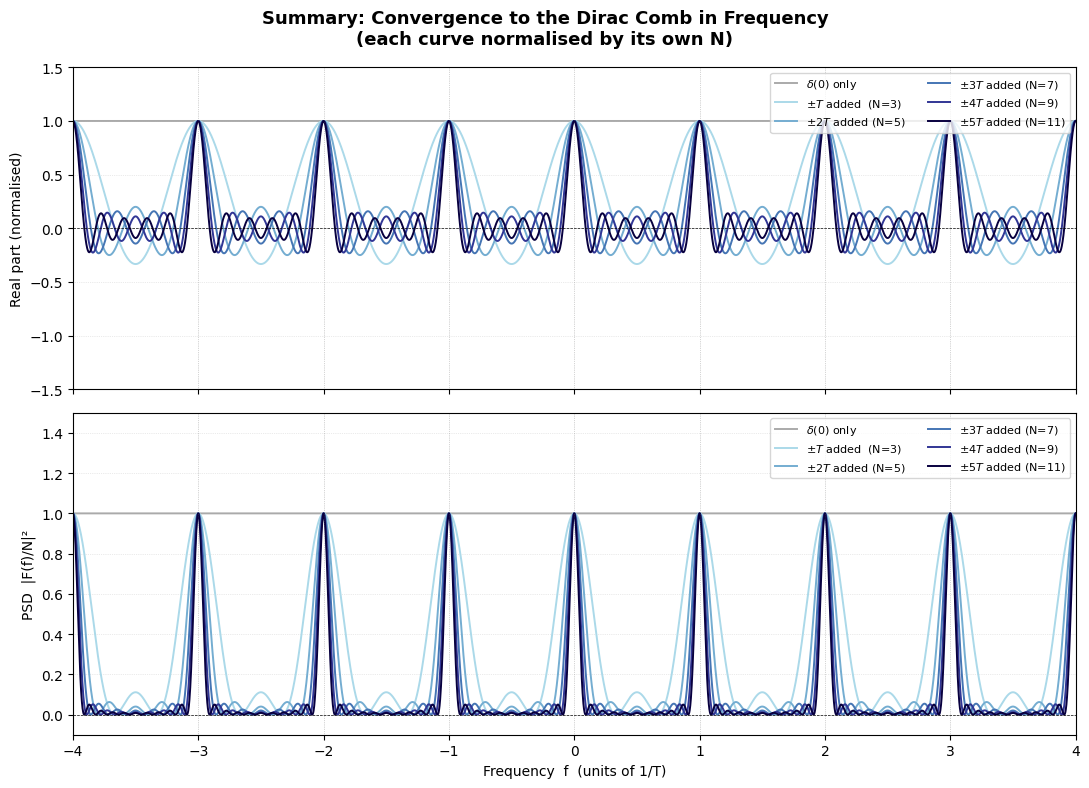

Max |imaginary part| for symmetric configurations (should be ~0):
  $\delta(0)$ only              max|imag| = 0.00e+00
  $\pm T$ added  (N=3)          max|imag| = 0.00e+00
  $\pm 2T$ added (N=5)          max|imag| = 0.00e+00
  $\pm 3T$ added (N=7)          max|imag| = 0.00e+00
  $\pm 4T$ added (N=9)          max|imag| = 0.00e+00
  $\pm 5T$ added (N=11)         max|imag| = 0.00e+00


In [10]:
configs = [
    (F1,  1,  r'$\delta(0)$ only',       '#aaaaaa'),
    (F4,  3,  r'$\pm T$ added  (N=3)',   '#abd9e9'),
    (F5,  5,  r'$\pm 2T$ added (N=5)',   '#74add1'),
    (F6,  7,  r'$\pm 3T$ added (N=7)',   '#4575b4'),
    (F7,  9,  r'$\pm 4T$ added (N=9)',   '#313695'),
    (F8, 11,  r'$\pm 5T$ added (N=11)',  '#08003f'),
]

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
fig.suptitle('Summary: Convergence to the Dirac Comb in Frequency\n'
             '(each curve normalised by its own N)',
             fontsize=13, fontweight='bold')

for F, N, label, color in configs:
    F_norm = F / N
    axes[0].plot(f, F_norm.real,      color=color, lw=1.4, label=label)
    axes[1].plot(f, np.abs(F_norm)**2, color=color, lw=1.4, label=label)

for ax in axes:
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.grid(ls=':', lw=0.5, alpha=0.5)
    for k in range(-4, 5):
        ax.axvline(k/T, color='grey', lw=0.5, ls=':', alpha=0.4)
    ax.legend(fontsize=8, loc='upper right', ncol=2)

axes[0].set_ylabel('Real part (normalised)', fontsize=10)
axes[0].set_ylim(-1.5, 1.5)
axes[1].set_ylabel('PSD  |F(f)/N|²', fontsize=10)
axes[1].set_ylim(-0.1, 1.5)
axes[1].set_xlabel('Frequency  f  (units of 1/T)', fontsize=10)
axes[0].set_xlim(f[0], f[-1])

fig.tight_layout()
plt.show()

# Verify imaginary parts are numerically zero for all symmetric configs
print('Max |imaginary part| for symmetric configurations (should be ~0):')
for F, N, label, _ in configs:
    print(f'  {label:28s}  max|imag| = {np.max(np.abs((F/N).imag)):.2e}')

---
## Conclusions

This notebook has demonstrated:

1. **A single $\delta(t)$ at the origin** has a flat real spectrum and zero imaginary spectrum. PSD = 1 everywhere.

2. **A single $\delta(t \pm T)$ off the origin** has both real (cosine) and imaginary (sine) parts.
   PSD is still flat — location information is encoded entirely in the phase.

3. **Symmetric pairs** around the origin have zero imaginary parts — a consequence of the
   even-function theorem, not a numerical accident.

4. **Progressive addition** of symmetric pairs causes constructive interference at $f = k/T$
   and destructive interference elsewhere — the Dirac comb in frequency emerges naturally.

5. **Normalising by N** keeps the peak amplitude fixed at 1, revealing that what changes
   with each added pair is the *shape* of the spectrum — sharpening peaks, suppressed sidelobes.

6. **The PSD cannot distinguish** the location of a single impulse — that information
   is in the phase, which the PSD discards. This is the fundamental limitation of
   spectrum analysers and periodogram methods when phase information is needed.

This result is the mathematical foundation of the Nyquist-Shannon sampling theorem
and is central to understanding aliasing in the Lomb-Scargle periodogram
(VanderPlas 2018, Section 3).